# EDA Notebook

Notebook này đã sẵn sàng để phân tích dữ liệu và trực quan hóa.

Data Understanding & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Tổng quan dataset

In [2]:
# Shape & data types
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\n--- Data Types ---")
print(df.dtypes.value_counts())

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f"\nColumns with missing values: {len(missing_df)}")
print(missing_df.head(20))

Rows: 307,511 | Columns: 122

--- Data Types ---
float64    65
int64      41
object     16
Name: count, dtype: int64

Columns with missing values: 67
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865        69.87
COMMONAREA_MODE                  214865        69.87
COMMONAREA_AVG                   214865        69.87
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_AVG             210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_MODE            210199        68.35
FLOORSMIN_MEDI                   208642        67.85
FLOORSMIN_MODE                   208642        67.85
FLOORSMIN_AVG                    208642        67.85
YEARS_BUILD_MODE                 204488        66.50
YEARS_BUILD_MEDI                 204488        66.50
YE

Phân tích Target (biến cần dự đoán)

=== TARGET Distribution ===
Trả được nợ (0): 282,686 (91.9%)
Vỡ nợ      (1): 24,825 (8.1%)


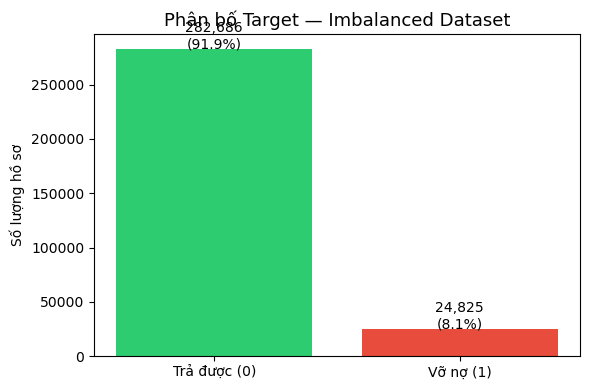

In [3]:
# Tỷ lệ vỡ nợ tổng thể
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("=== TARGET Distribution ===")
print(f"Trả được nợ (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Vỡ nợ      (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Trả được (0)', 'Vỡ nợ (1)'], target_counts, color=['#2ecc71', '#e74c3c'])
ax.set_title('Phân bố Target — Imbalanced Dataset', fontsize=13)
ax.set_ylabel('Số lượng hồ sơ')
for i, v in enumerate(target_counts):
    ax.text(i, v + 1000, f'{v:,}\n({target_pct[i]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Default rate theo từng segment

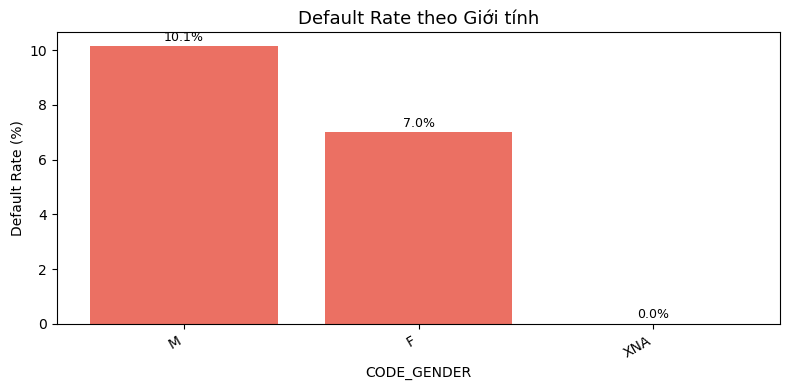

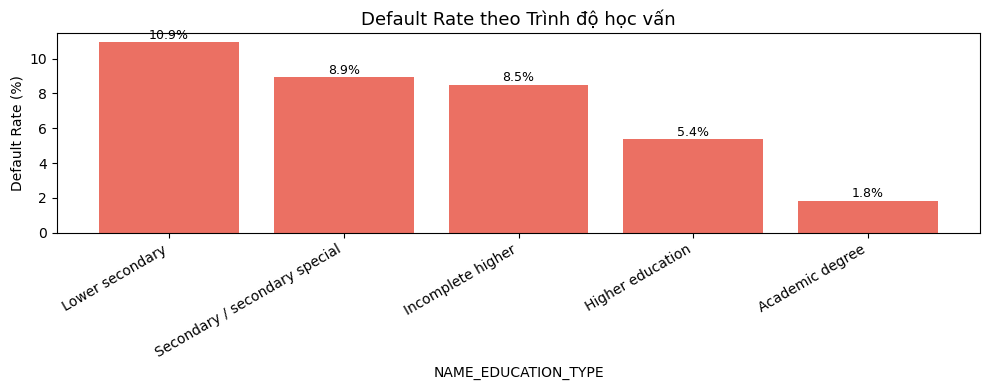

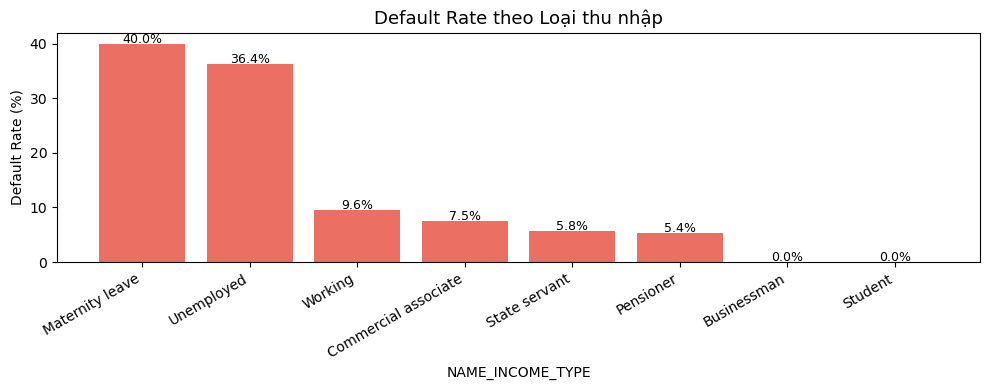

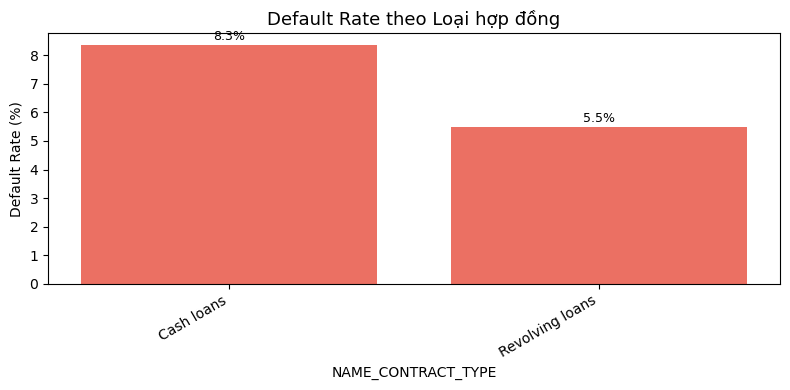

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64

In [4]:
# Hàm tiện ích
def default_rate_plot(col, title, figsize=(8, 4)):
    rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(rate.index, rate.values, color='#e74c3c', alpha=0.8)
    ax.set_title(f'Default Rate theo {title}', fontsize=13)
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)
    plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return rate

# Chạy từng segment
default_rate_plot('CODE_GENDER', 'Giới tính')
default_rate_plot('NAME_EDUCATION_TYPE', 'Trình độ học vấn', figsize=(10, 4))
default_rate_plot('NAME_INCOME_TYPE', 'Loại thu nhập', figsize=(10, 4))
default_rate_plot('NAME_CONTRACT_TYPE', 'Loại hợp đồng')

Phân tích biến số (numerical)

C:\Users\trant\AppData\Local\Temp\ipykernel_17364\85530959.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100


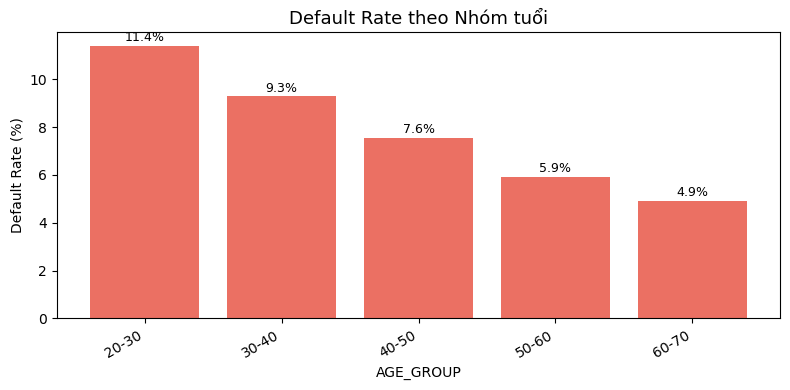

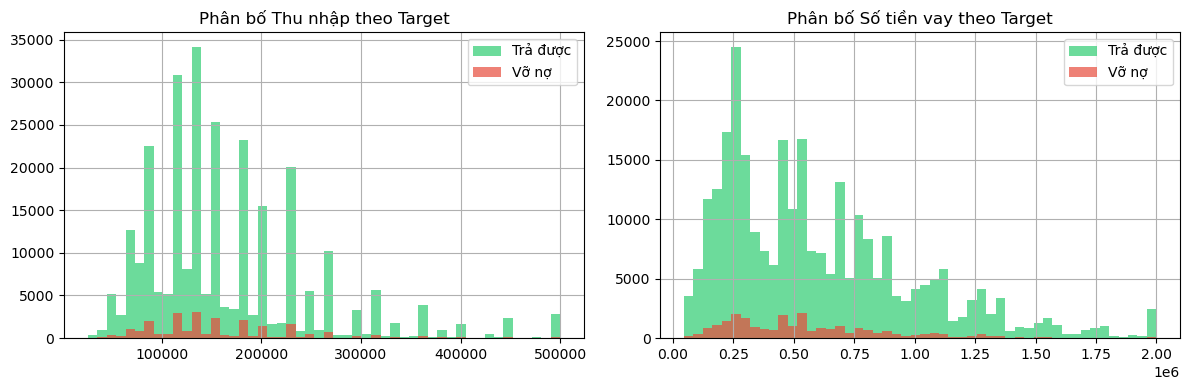

In [5]:
# Tạo age từ DAYS_BIRTH
df['AGE_YEARS'] = (df['DAYS_BIRTH'] / -365).astype(int)
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70],
                          labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

default_rate_plot('AGE_GROUP', 'Nhóm tuổi')

# Income vs Default
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['TARGET']==0]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=axes[0], color='#2ecc71', alpha=0.7, label='Trả được')
df[df['TARGET']==1]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=axes[0], color='#e74c3c', alpha=0.7, label='Vỡ nợ')
axes[0].set_title('Phân bố Thu nhập theo Target')
axes[0].legend()

# Credit Amount
df[df['TARGET']==0]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=axes[1], color='#2ecc71', alpha=0.7, label='Trả được')
df[df['TARGET']==1]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=axes[1], color='#e74c3c', alpha=0.7, label='Vỡ nợ')
axes[1].set_title('Phân bố Số tiền vay theo Target')
axes[1].legend()
plt.tight_layout()
plt.show()

Data Preparation

In [6]:
# 1. Drop các cột missing quá nhiều (> 50%)
threshold = 0.5
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold * 100].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns | Còn lại: {df_clean.shape[1]} columns")

# 2. Tạo thêm features có ý nghĩa business
df_clean['CREDIT_INCOME_RATIO'] = df_clean['AMT_CREDIT'] / df_clean['AMT_INCOME_TOTAL']
df_clean['ANNUITY_INCOME_RATIO'] = df_clean['AMT_ANNUITY'] / df_clean['AMT_INCOME_TOTAL']
df_clean['AGE_YEARS'] = (df_clean['DAYS_BIRTH'] / -365).astype(int)
df_clean['EMPLOY_YEARS'] = (df_clean['DAYS_EMPLOYED'].clip(upper=0) / -365).astype(int)

# 3. Fill missing cho các cột còn lại
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna(df_clean[cat_cols].mode().iloc[0])

# 4. Encode categorical
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"Final shape: {df_encoded.shape}")

# Save
df_encoded.to_csv('data/processed/application_clean.csv', index=False)
print("Saved!")

Dropped 41 columns | Còn lại: 83 columns
Final shape: (307511, 186)
Saved!


Modeling với XGBoost

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Tách X, y
X = df_encoded.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_encoded['TARGET']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]:,}")
print(f"Default rate: {y.mean():.2%}")

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Features: 184 | Samples: 307,511
Default rate: 8.07%

Train: 246,008 | Test: 61,503


In [10]:
# Fix: drop AGE_GROUP (đã có AGE_YEARS rồi, không cần nữa)
X = df_encoded.drop(columns=['TARGET', 'SK_ID_CURR', 'AGE_GROUP'], errors='ignore')
y = df_encoded['TARGET']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]:,}")

# Đảm bảo tất cả cột đều là số
X = X.astype(float)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Features: 183 | Samples: 307,511
Train: 246,008 | Test: 61,503


In [11]:
# 3. Train XGBoost (xử lý imbalanced bằng scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.1f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,   # xử lý imbalanced
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

scale_pos_weight = 11.4
[0]	validation_0-auc:0.71025
[50]	validation_0-auc:0.74065
[100]	validation_0-auc:0.74917
[150]	validation_0-auc:0.75209
[200]	validation_0-auc:0.75344
[250]	validation_0-auc:0.75478
[299]	validation_0-auc:0.75564


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)


🎯 AUC-ROC Score: 0.7557


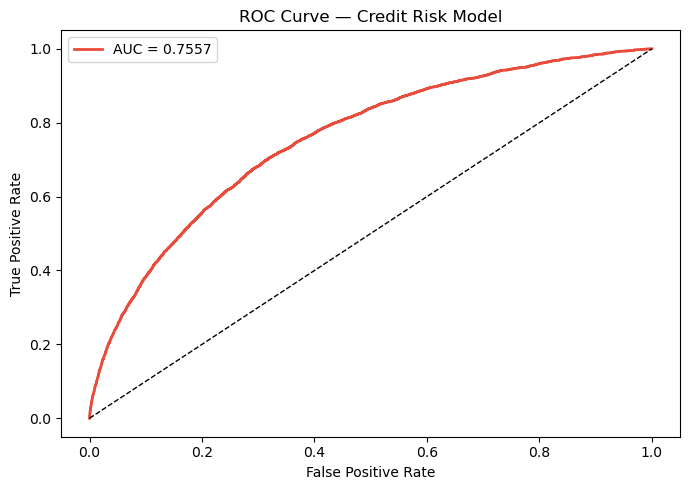

In [ ]:
# 4. Đánh giá model
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC Score: {auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Risk Model')
plt.legend()
plt.tight_layout()
plt.show()

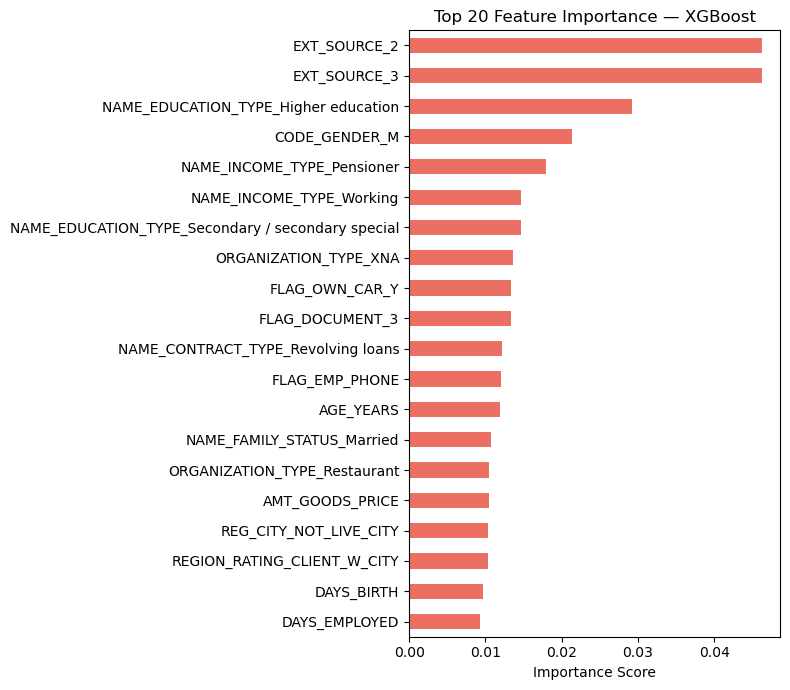


Top 10 features:
EXT_SOURCE_2                                         0.046302
EXT_SOURCE_3                                         0.046277
NAME_EDUCATION_TYPE_Higher education                 0.029148
CODE_GENDER_M                                        0.021281
NAME_INCOME_TYPE_Pensioner                           0.017972
NAME_INCOME_TYPE_Working                             0.014693
NAME_EDUCATION_TYPE_Secondary / secondary special    0.014663
ORGANIZATION_TYPE_XNA                                0.013637
FLAG_OWN_CAR_Y                                       0.013406
FLAG_DOCUMENT_3                                      0.013307
dtype: float32


In [13]:
# 5. Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top20.sort_values().plot(kind='barh', color='#e74c3c', alpha=0.8)
plt.title('Top 20 Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top20.head(10))